In [2]:
# ============================================
# Step 1: Import Required Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")




In [3]:



# ============================================
# Step 2: Create Dummy Churn Dataset
# ============================================

np.random.seed(42)

n = 5000

customer_id = np.arange(1, n + 1)

gender = np.random.choice(['Male', 'Female'], size=n)

age = np.random.randint(18, 70, size=n)

tenure_months = np.random.randint(1, 72, size=n)

monthly_bill = np.random.randint(300, 3000, size=n)

internet_usage_gb = np.random.randint(1, 250, size=n)

complaints = np.random.randint(0, 8, size=n)

contract_type = np.random.choice(
    ['Prepaid', 'Monthly', 'Yearly'],
    size=n,
    p=[0.45, 0.40, 0.15]
)

payment_delay = np.random.randint(0, 20, size=n)

network_quality = np.random.choice(
    ['Poor', 'Average', 'Good'],
    size=n,
    p=[0.25, 0.45, 0.30]
)

customer_satisfaction = np.random.randint(1, 6, size=n)

competitor_offer = np.random.choice(
    ['Yes', 'No'],
    size=n,
    p=[0.35, 0.65]
)

# Creating churn probability logically
churn_probability = (
    0.15
    + (monthly_bill > 1800) * 0.15
    + (complaints > 3) * 0.20
    + (payment_delay > 10) * 0.10
    + (network_quality == 'Poor') * 0.20
    + (customer_satisfaction <= 2) * 0.20
    + (contract_type == 'Prepaid') * 0.08
    + (competitor_offer == 'Yes') * 0.12
    - (tenure_months > 36) * 0.10
    - (contract_type == 'Yearly') * 0.12
)

churn_probability = np.clip(churn_probability, 0, 1)

churn = np.random.binomial(1, churn_probability)

df = pd.DataFrame({
    'Customer_ID': customer_id,
    'Gender': gender,
    'Age': age,
    'Tenure_Months': tenure_months,
    'Monthly_Bill': monthly_bill,
    'Internet_Usage_GB': internet_usage_gb,
    'Complaints': complaints,
    'Contract_Type': contract_type,
    'Payment_Delay_Days': payment_delay,
    'Network_Quality': network_quality,
    'Customer_Satisfaction': customer_satisfaction,
    'Competitor_Offer': competitor_offer,
    'Churn': churn
})

df.head()



,Customer_ID,Gender,Age,Tenure_Months,Monthly_Bill,Internet_Usage_GB,Complaints,Contract_Type,Payment_Delay_Days,Network_Quality,Customer_Satisfaction,Competitor_Offer,Churn
0,1,Male,68,66,889,169,1,Monthly,17,Good,1,Yes,0
1,2,Female,64,54,2251,103,6,Prepaid,1,Average,2,No,1
2,3,Male,64,27,1255,98,7,Monthly,19,Poor,3,No,1
3,4,Male,21,38,2886,115,1,Monthly,9,Average,4,No,1
4,5,Male,24,58,1443,40,6,Prepaid,11,Poor,1,No,1


In [4]:
df

,Customer_ID,Gender,Age,Tenure_Months,Monthly_Bill,Internet_Usage_GB,Complaints,Contract_Type,Payment_Delay_Days,Network_Quality,Customer_Satisfaction,Competitor_Offer,Churn
0,1,Male,68,66,889,169,1,Monthly,17,Good,1,Yes,0
1,2,Female,64,54,2251,103,6,Prepaid,1,Average,2,No,1
2,3,Male,64,27,1255,98,7,Monthly,19,Poor,3,No,1
3,4,Male,21,38,2886,115,1,Monthly,9,Average,4,No,1
4,5,Male,24,58,1443,40,6,Prepaid,11,Poor,1,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,Male,48,8,571,67,4,Prepaid,0,Average,1,No,1
4996,4997,Female,30,55,1348,85,6,Prepaid,10,Average,2,No,1
4997,4998,Male,33,69,2258,57,3,Monthly,18,Poor,3,No,1
4998,4999,Female,60,44,2669,72,4,Monthly,3,Average,4,Yes,1


In [5]:
# ============================================
# Step 4: Basic Dataset Information
# ============================================

df.shape

(5000, 13)

In [6]:
# ============================================
# Step 4: Basic Dataset Information
# ============================================

df.shape

(5000, 13)

In [7]:
df.describe()

,Customer_ID,Age,Tenure_Months,Monthly_Bill,Internet_Usage_GB,Complaints,Payment_Delay_Days,Customer_Satisfaction,Churn
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,43.420800,36.103400,1655.25480,125.029200,3.502000,9.620200,2.996000,0.49680
std,1443.520003,14.901159,20.505375,768.88796,71.705611,2.282244,5.710593,1.399849,0.50004
min,1.000000,18.000000,1.000000,300.00000,1.000000,0.000000,0.000000,1.000000,0.00000
25%,1250.750000,31.000000,18.000000,1005.75000,63.750000,2.000000,5.000000,2.000000,0.00000
50%,2500.500000,43.000000,36.000000,1656.00000,125.000000,3.000000,10.000000,3.000000,0.00000
75%,3750.250000,56.000000,54.000000,2304.50000,187.000000,5.000000,15.000000,4.000000,1.00000
max,5000.000000,69.000000,71.000000,2999.00000,249.000000,7.000000,19.000000,5.000000,1.00000


In [8]:
df.isnull().sum()

,0
Customer_ID,0
Gender,0
Age,0
Tenure_Months,0
Monthly_Bill,0
Internet_Usage_GB,0
Complaints,0
Contract_Type,0
Payment_Delay_Days,0
Network_Quality,0


In [9]:
# ============================================
# Step 5: Churn Count
# ============================================

df['Churn'].value_counts()

,count
Churn,
0,2516
1,2484


In [10]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,50.32
1,49.68


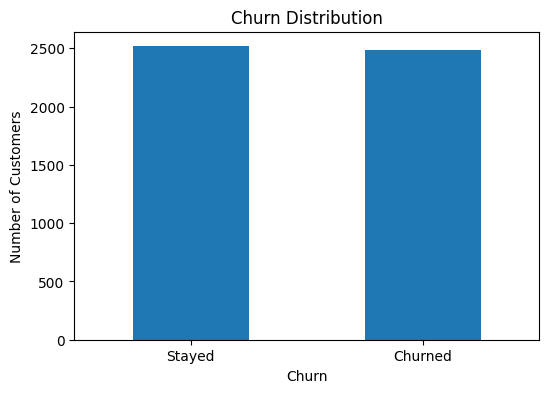

In [11]:
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks([0,1], ['Stayed', 'Churned'], rotation=0)
plt.show()

In [12]:
# ============================================
# Step 6: Monthly Bill Analysis
# ============================================

df.groupby('Churn')['Monthly_Bill'].mean()

,Monthly_Bill
Churn,
0,1563.319555
1,1748.374396


<Figure size 700x400 with 0 Axes>

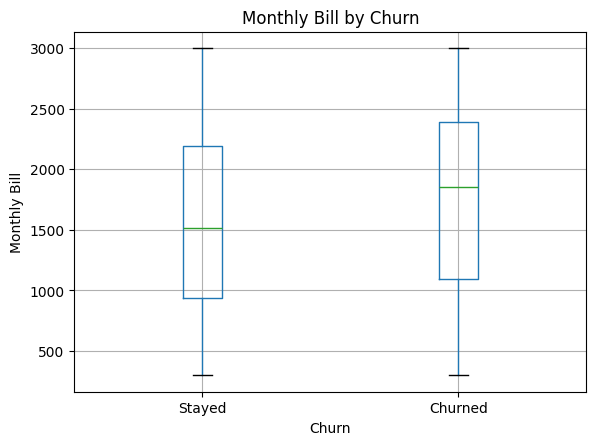

In [13]:
plt.figure(figsize=(7,4))
df.boxplot(column='Monthly_Bill', by='Churn')
plt.title('Monthly Bill by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Bill')
plt.xticks([1,2], ['Stayed', 'Churned'])
plt.show()

In [14]:
# ============================================
# Step 7: Complaints and Churn
# ============================================

df.groupby('Churn')['Complaints'].mean()

,Complaints
Churn,
0,3.096184
1,3.913043


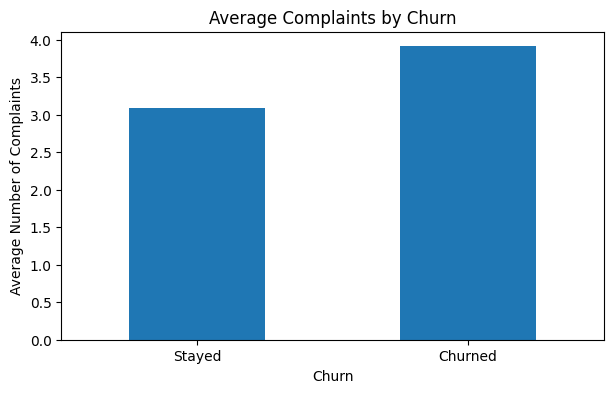

In [15]:
plt.figure(figsize=(7,4))
df.groupby('Churn')['Complaints'].mean().plot(kind='bar')
plt.title('Average Complaints by Churn')
plt.xlabel('Churn')
plt.ylabel('Average Number of Complaints')
plt.xticks([0,1], ['Stayed', 'Churned'], rotation=0)
plt.show()

In [16]:
# ============================================
# Step 8: Network Quality and Churn
# ============================================

network_churn = pd.crosstab(df['Network_Quality'], df['Churn'])
network_churn

Churn,0,1
Network_Quality,,
Average,1270,1012
Good,785,661
Poor,461,811


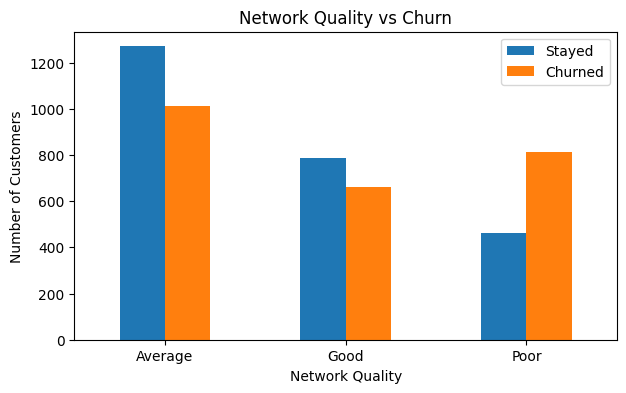

In [17]:
network_churn.plot(kind='bar', figsize=(7,4))
plt.title('Network Quality vs Churn')
plt.xlabel('Network Quality')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Churned'])
plt.xticks(rotation=0)
plt.show()

In [18]:
# ============================================
# Step 11: Competitor Offer and Churn
# ============================================

competitor_churn = pd.crosstab(df['Competitor_Offer'], df['Churn'])
competitor_churn

Churn,0,1
Competitor_Offer,,
No,1768,1480
Yes,748,1004


In [19]:
# ============================================
# Step 11: Competitor Offer and Churn
# ============================================

competitor_churn = pd.crosstab(df['Competitor_Offer'], df['Churn'])
competitor_churn

Churn,0,1
Competitor_Offer,,
No,1768,1480
Yes,748,1004


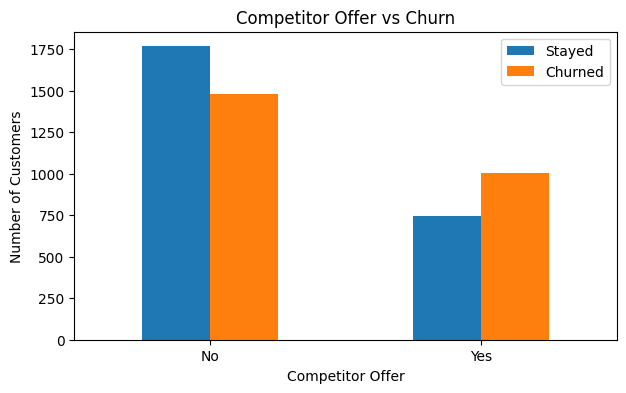

In [20]:
competitor_churn.plot(kind='bar', figsize=(7,4))
plt.title('Competitor Offer vs Churn')
plt.xlabel('Competitor Offer')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Churned'])
plt.xticks(rotation=0)
plt.show()